In [1]:
# Импорт необходимых библиотек
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

# Параметры генерации
M = 500  # Количество точек
sigma1 = 0.3  # Стандартное отклонение первого признака
sigma2 = 0.8  # Стандартное отклонение второго признака
alpha = np.radians(30)  # Угол поворота в радианах

# Шаг 1: Генерация независимых векторов
np.random.seed(42)  # Фиксация seed для воспроизводимости
x1 = np.random.normal(0, sigma1, M)  # x1 ~ N(0, sigma1^2)
x2 = np.random.normal(0, sigma2, M)  # x2 ~ N(0, sigma2^2)
X_independent = np.column_stack([x1, x2])  # Объединение в матрицу (M, 2)

# Шаг 2: Матрица поворота
# R = [[cos(alpha), -sin(alpha)],
#      [sin(alpha),  cos(alpha)]]
R = np.array([
    [np.cos(alpha), -np.sin(alpha)],
    [np.sin(alpha),  np.cos(alpha)]
])

# Применение поворота: X_rotated = X_independent @ R.T
X = X_independent @ R.T  # Транспонирование, т.к. умножаем строки на матрицу

# Шаг 3: Выборочная матрица ковариации
cov_sample = np.cov(X.T)  # np.cov ожидает признаки по строкам, поэтому .T
print("Выборочная матрица ковариации:\n", cov_sample)

# Шаг 4: Теоретическая матрица ковариации
# C_теор = R @ diag(sigma1^2, sigma2^2) @ R^T
D = np.diag([sigma1**2, sigma2**2])  # Диагональная матрица дисперсий
cov_theory = R @ D @ R.T
print("Теоретическая матрица ковариации:\n", cov_theory)

# Сравнение
print("\nРазница между выборочной и теоретической:\n", cov_sample - cov_theory)

# Автопроверка
assert X.shape == (M, 2), "Неверная размерность данных"
assert np.abs(np.cov(X.T)[0, 1]) > 0.1, "Корреляция слишком мала (проверьте поворот)"
assert np.allclose(np.mean(X, axis=0), 0, atol=0.1), "Среднее должно быть около 0"
print("\nВсе проверки пройдены!")

Выборочная матрица ковариации:
 [[ 0.23312293 -0.23625764]
 [-0.23625764  0.46568054]]
Теоретическая матрица ковариации:
 [[ 0.2275     -0.23815699]
 [-0.23815699  0.5025    ]]

Разница между выборочной и теоретической:
 [[ 0.00562293  0.00189935]
 [ 0.00189935 -0.03681946]]

Все проверки пройдены!


/tmp/ipykernel_889/505568693.py:27: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contour(X_grid, Y_grid, Z, levels=[level_value],


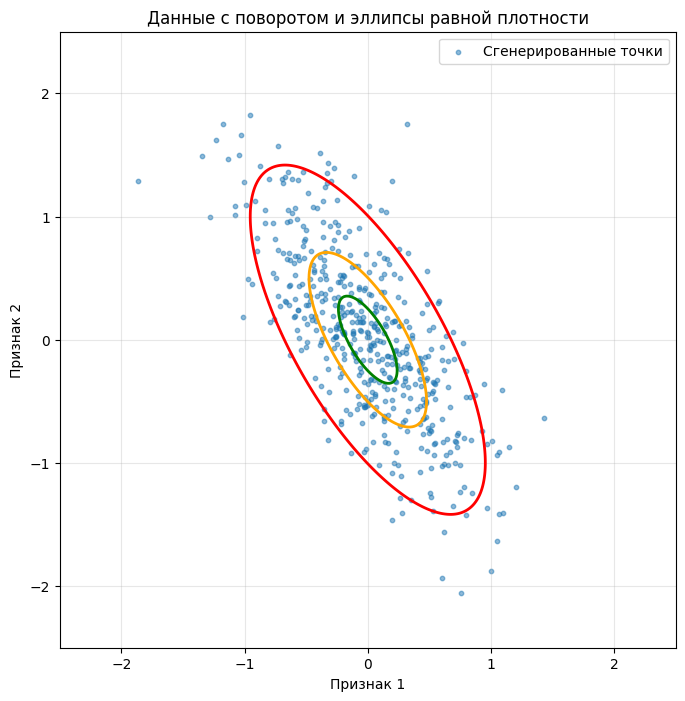

In [2]:
# Визуализация: scatter plot + эллипсы равной плотности
fig, ax = plt.subplots(figsize=(8, 8))

# Scatter plot полученных точек
ax.scatter(X[:, 0], X[:, 1], alpha=0.5, s=10, label='Сгенерированные точки')

# Эллипсы равной плотности для теоретического распределения
# Уровни: 0.5, 1, 2 стандартных отклонения
levels = [0.5, 1, 2]
colors = ['green', 'orange', 'red']

# Создание сетки для contour
x_grid = np.linspace(-2.5, 2.5, 300)
y_grid = np.linspace(-2.5, 2.5, 300)
X_grid, Y_grid = np.meshgrid(x_grid, y_grid)
pos = np.dstack((X_grid, Y_grid))

# Вычисление PDF теоретического распределения
rv = multivariate_normal(mean=[0, 0], cov=cov_theory)
Z = rv.pdf(pos)

# Построение контуров на уровнях, соответствующих 0.5, 1, 2 сигма
# Для 2D нормального распределения плотность на уровне k сигма:
# pdf = (1/(2*pi*|C|^0.5)) * exp(-k^2/2)
for k, color in zip(levels, colors):
    level_value = rv.pdf([0, 0]) * np.exp(-k**2 / 2)
    ax.contour(X_grid, Y_grid, Z, levels=[level_value],
               colors=[color], linewidths=2,
               label=f'{k} сигма' if k == 0.5 else "")

ax.set_xlabel('Признак 1')
ax.set_ylabel('Признак 2')
ax.set_title('Данные с поворотом и эллипсы равной плотности')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')
plt.show()

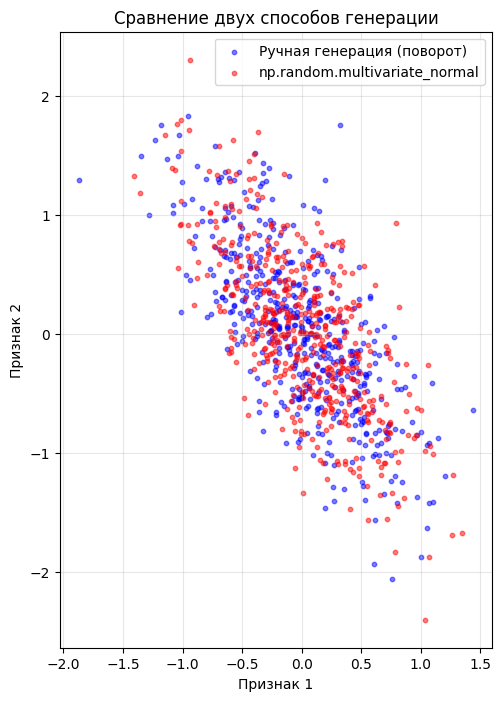

In [3]:
# Генерация точек с помощью np.random.multivariate_normal
np.random.seed(42)
X_builtin = np.random.multivariate_normal(mean=[0, 0], cov=cov_theory, size=M)

# Визуализация обоих облаков точек
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(X[:, 0], X[:, 1], alpha=0.5, s=10, c='blue', label='Ручная генерация (поворот)')
ax.scatter(X_builtin[:, 0], X_builtin[:, 1], alpha=0.5, s=10, c='red', label='np.random.multivariate_normal')
ax.set_xlabel('Признак 1')
ax.set_ylabel('Признак 2')
ax.set_title('Сравнение двух способов генерации')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')
plt.show()

### Вопрос 1.2: Совпадают ли облака визуально? Почему встроенная функция может быть предпочтительнее?

**Ответ:**

Визуально облака точек **совпадают** — оба метода генерируют выборки из одного и того же двумерного нормального распределения с математическим ожиданием (0, 0) и ковариационной матрицей `cov_theory`. Небольшие различия в расположении точек обусловлены случайностью выборки (разные реализации генератора случайных чисел), но статистические характеристики (среднее, ковариация, форма облака) идентичны.

**Преимущества `np.random.multivariate_normal`:**
1. **Простота и краткость** — одна строка вместо нескольких шагов (генерация независимых компонент, построение матрицы поворота, умножение).
2. **Численная устойчивость** — функция использует разложение Холецкого для генерации, что гарантирует корректную работу с любой положительно определённой ковариационной матрицей.
3. **Масштабируемость** — легко генерировать данные в пространстве любой размерности, тогда как ручной метод требует явного построения матрицы поворота.
4. **Меньше ошибок** — исключаются ошибки, связанные с порядком умножения матриц (например, `X @ R.T` vs `X @ R`).
5. **Стандартность** — код понятен другим разработчикам без дополнительных пояснений.

**Когда ручной метод полезен:**
- Для **образовательных целей** — понимания геометрического смысла ковариации.
- Когда нужно **контролировать** процесс генерации (например, использовать специфический генератор случайных чисел).
- Для генерации данных с **нестандартной структурой** (например, смесь распределений).

Оценка среднего: [-0.01095388  0.02307548]
Оценка ковариации:
[[ 0.23312293 -0.23625764]
 [-0.23625764  0.46568054]]
Максимальная разница между ручным и scipy вычислением: 2.78e-16
Проверка пройдена!


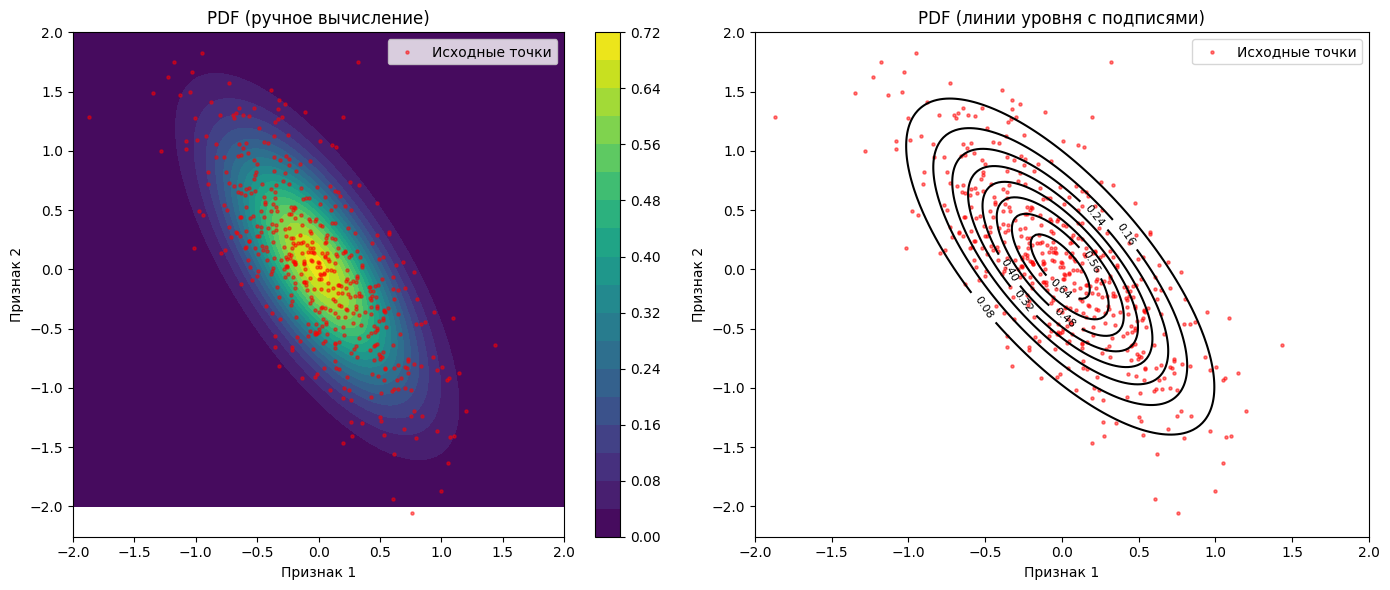

In [4]:
# Шаг 1: Оценка параметров по данным из п. 1.1
mu_hat = np.mean(X, axis=0)  # Выборочное среднее
C_hat = np.cov(X.T)  # Выборочная ковариация
print(f"Оценка среднего: {mu_hat}")
print(f"Оценка ковариации:\n{C_hat}")

# Шаг 2: Создание сетки точек
x = np.linspace(-2, 2, 200)
y = np.linspace(-2, 2, 200)
X_grid, Y_grid = np.meshgrid(x, y)
grid_points = np.dstack((X_grid, Y_grid))  # Форма (200, 200, 2)

# Шаг 3: Вычисление PDF двумя способами

# Способ 1: scipy.stats.multivariate_normal
m = multivariate_normal(mean=mu_hat, cov=C_hat)
pdf_scipy = m.pdf(grid_points)

# Способ 2: Ручное вычисление по формуле
# PDF(x) = (1 / ((2*pi)^(d/2) * |C|^(1/2))) * exp(-0.5 * (x-mu)^T @ C^(-1) @ (x-mu))
def manual_pdf(X_grid, Y_grid, mean, cov):
    """
    Ручное вычисление PDF двумерного нормального распределения.

    Параметры:
    -----------
    X_grid, Y_grid : np.ndarray
        Сетки координат
    mean : np.ndarray
        Вектор средних (2,)
    cov : np.ndarray
        Ковариационная матрица (2, 2)

    Возвращает:
    -----------
    pdf : np.ndarray
        Значения плотности в точках сетки
    """
    d = 2  # Размерность
    det_cov = np.linalg.det(cov)  # Определитель ковариации
    inv_cov = np.linalg.inv(cov)  # Обратная ковариация

    # Нормировочная константа
    norm_const = 1.0 / ((2 * np.pi) ** (d / 2) * np.sqrt(det_cov))

    # Вычисление квадратичной формы для каждой точки
    # (x - mu)^T @ C^(-1) @ (x - mu)
    diff_x = X_grid - mean[0]
    diff_y = Y_grid - mean[1]

    # Квадратичная форма (для 2D)
    # Q = [dx, dy] @ [[inv00, inv01], [inv10, inv11]] @ [dx, dy]^T
    Q = (inv_cov[0, 0] * diff_x**2 +
         (inv_cov[0, 1] + inv_cov[1, 0]) * diff_x * diff_y +
         inv_cov[1, 1] * diff_y**2)

    pdf = norm_const * np.exp(-0.5 * Q)
    return pdf

pdf_manual = manual_pdf(X_grid, Y_grid, mu_hat, C_hat)

# Шаг 4: Сравнение результатов
max_diff = np.max(np.abs(pdf_manual - pdf_scipy))
print(f"Максимальная разница между ручным и scipy вычислением: {max_diff:.2e}")
assert max_diff < 1e-10, "Ручное вычисление отличается от scipy"
print("Проверка пройдена!")

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Contour plot с заливкой
cf = axes[0].contourf(X_grid, Y_grid, pdf_manual, levels=20, cmap='viridis')
axes[0].scatter(X[:, 0], X[:, 1], c='red', s=5, alpha=0.5, label='Исходные точки')
axes[0].set_xlabel('Признак 1')
axes[0].set_ylabel('Признак 2')
axes[0].set_title('PDF (ручное вычисление)')
axes[0].legend()
plt.colorbar(cf, ax=axes[0])

# Contour с подписями значений
cs = axes[1].contour(X_grid, Y_grid, pdf_manual, levels=10, colors='black')
axes[1].clabel(cs, inline=True, fontsize=8)
axes[1].scatter(X[:, 0], X[:, 1], c='red', s=5, alpha=0.5, label='Исходные точки')
axes[1].set_xlabel('Признак 1')
axes[1].set_ylabel('Признак 2')
axes[1].set_title('PDF (линии уровня с подписями)')
axes[1].legend()

plt.tight_layout()
plt.show()

In [5]:
# Параметры классов
mu0 = np.array([-0.5, 0.5])
mu1 = np.array([0.5, -0.5])
C0 = np.array([[0.2, 0.1], [0.1, 0.3]])
C1 = np.array([[0.3, -0.1], [-0.1, 0.2]])

n_samples = 300  # По 300 точек на класс

# Генерация данных
np.random.seed(42)
X0 = np.random.multivariate_normal(mu0, C0, n_samples)
X1 = np.random.multivariate_normal(mu1, C1, n_samples)

# Объединение
X = np.vstack([X0, X1])
y = np.hstack([np.zeros(n_samples), np.ones(n_samples)])

# Априорные вероятности (оцениваются как доли классов)
prior0 = n_samples / (2 * n_samples)  # 0.5
prior1 = n_samples / (2 * n_samples)  # 0.5
print(f"Априорные вероятности: p(y=0)={prior0}, p(y=1)={prior1}")

Априорные вероятности: p(y=0)=0.5, p(y=1)=0.5


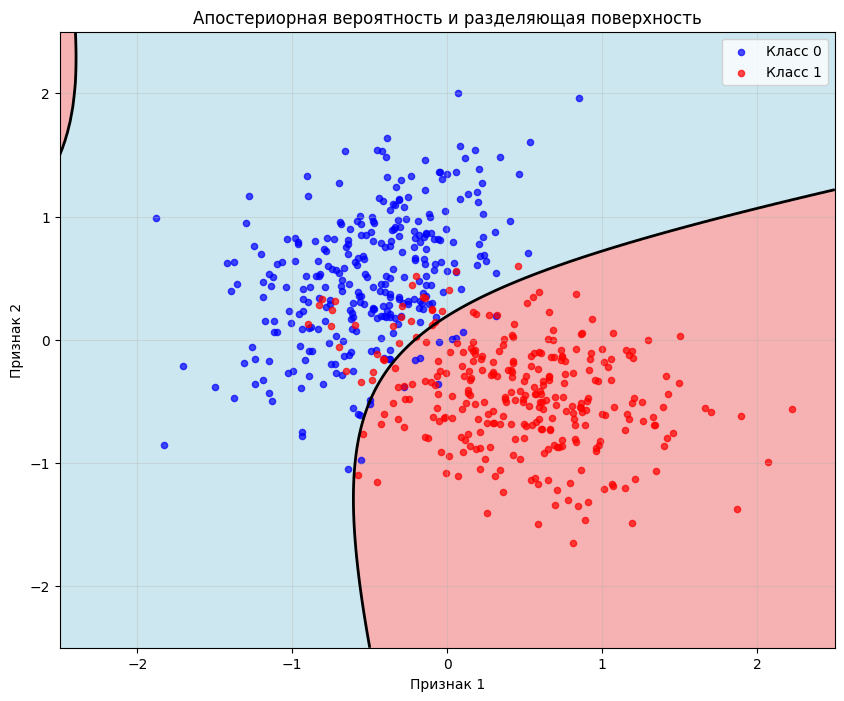

In [6]:
# Создание сетки
x_grid = np.linspace(-2.5, 2.5, 300)
y_grid = np.linspace(-2.5, 2.5, 300)
X_grid, Y_grid = np.meshgrid(x_grid, y_grid)
grid_points = np.dstack((X_grid, Y_grid))

# Вычисление правдоподобий
rv0 = multivariate_normal(mean=mu0, cov=C0)
rv1 = multivariate_normal(mean=mu1, cov=C1)

pdf0 = rv0.pdf(grid_points)  # p(x|y=0)
pdf1 = rv1.pdf(grid_points)  # p(x|y=1)

# Вычисление Δ(x) = p(x|y=0)*p(y=0) - p(x|y=1)*p(y=1)
# Используем логарифмы для численной устойчивости
log_pdf0 = rv0.logpdf(grid_points)
log_pdf1 = rv1.logpdf(grid_points)

# Δ в логарифмическом масштабе (для визуализации)
# Но для заливки фона используем знак Δ
Delta = pdf0 * prior0 - pdf1 * prior1

# Визуализация
fig, ax = plt.subplots(figsize=(10, 8))

# Заливка фона: положительные Δ — синим, отрицательные — красным
# Используем contourf с двумя уровнями
ax.contourf(X_grid, Y_grid, Delta, levels=[Delta.min(), 0, Delta.max()],
            colors=['lightcoral', 'lightblue'], alpha=0.6)

# Scatter plot точек классов
ax.scatter(X0[:, 0], X0[:, 1], c='blue', s=20, alpha=0.7, label='Класс 0')
ax.scatter(X1[:, 0], X1[:, 1], c='red', s=20, alpha=0.7, label='Класс 1')

# Разделяющая поверхность: Δ(x) = 0
ax.contour(X_grid, Y_grid, Delta, levels=[0], colors='black', linewidths=2)

ax.set_xlabel('Признак 1')
ax.set_ylabel('Признак 2')
ax.set_title('Апостериорная вероятность и разделяющая поверхность')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

### Вопрос 3.2: Является ли разделяющая поверхность линейной? Почему?

**Ответ:**

Разделяющая поверхность **не является линейной** в общем случае, когда ковариационные матрицы классов различаются ($C_0 \neq C_1$).

**Математическое обоснование:**

Разделяющая поверхность определяется уравнением $\Delta(x) = 0$, где:
$$\Delta(x) = p(x|y=0) \cdot p(y=0) - p(x|y=1) \cdot p(y=1)$$

Подставляя выражения для многомерных нормальных плотностей:
$$p(x|y=k) = \frac{1}{(2\pi)^{d/2} |C_k|^{1/2}} \exp\left(-\frac{1}{2}(x-\mu_k)^T C_k^{-1} (x-\mu_k)\right)$$

Получаем, что $\Delta(x) = 0$ эквивалентно:
$$\log p(y=0) - \frac{1}{2}\log|C_0| - \frac{1}{2}(x-\mu_0)^T C_0^{-1}(x-\mu_0) = \log p(y=1) - \frac{1}{2}\log|C_1| - \frac{1}{2}(x-\mu_1)^T C_1^{-1}(x-\mu_1)$$

Это уравнение содержит **квадратичные по $x$ члены** (вида $x^T C_k^{-1} x$). Если $C_0 \neq C_1$, то квадратичные члены не сокращаются, и разделяющая поверхность является **квадратичной** (квадратичный дискриминантный анализ, QDA).

**Когда поверхность линейна:**
Только при $C_0 = C_1 = C$ квадратичные члены сокращаются, и уравнение становится линейным относительно $x$ — это и есть LDA.

В нашем случае $C_0 \neq C_1$, поэтому поверхность **нелинейная** (квадратичная).

### 4.1 Теоретический вывод разделяющей поверхности для LDA

**Дано:** $C_0 = C_1 = C$, $p(x|y=k) = \mathcal{N}(\mu_k, C)$.

**Байесовский классификатор:**
$$\hat{y} = \arg\max_k \left[ \log p(y=k) + \log p(x|y=k) \right]$$

**Логарифм правдоподобия:**
$$\log p(x|y=k) = -\frac{d}{2}\log(2\pi) - \frac{1}{2}\log|C| - \frac{1}{2}(x-\mu_k)^T C^{-1} (x-\mu_k)$$

**Разность для классов 1 и 0:**
$$\log \frac{p(y=1|x)}{p(y=0|x)} = \log \frac{p(y=1)}{p(y=0)} + \log \frac{p(x|y=1)}{p(x|y=0)}$$

Члены $-\frac{d}{2}\log(2\pi)$ и $-\frac{1}{2}\log|C|$ сокращаются:
$$= \log \frac{p(y=1)}{p(y=0)} - \frac{1}{2}(x-\mu_1)^T C^{-1}(x-\mu_1) + \frac{1}{2}(x-\mu_0)^T C^{-1}(x-\mu_0)$$

**Раскрываем квадратичные формы:**
$$(x-\mu_k)^T C^{-1}(x-\mu_k) = x^T C^{-1} x - 2\mu_k^T C^{-1} x + \mu_k^T C^{-1} \mu_k$$

Подставляем:
$$= \log \frac{p(y=1)}{p(y=0)} - \frac{1}{2}\left[ x^T C^{-1} x - 2\mu_1^T C^{-1} x + \mu_1^T C^{-1} \mu_1 \right] + \frac{1}{2}\left[ x^T C^{-1} x - 2\mu_0^T C^{-1} x + \mu_0^T C^{-1} \mu_0 \right]$$

Члены $x^T C^{-1} x$ **сокращаются** (ключевой момент!):
$$= \log \frac{p(y=1)}{p(y=0)} + (\mu_1 - \mu_0)^T C^{-1} x - \frac{1}{2}\mu_1^T C^{-1} \mu_1 + \frac{1}{2}\mu_0^T C^{-1} \mu_0$$

**Итоговое уравнение разделяющей поверхности** $w^T x + b = 0$:

$$\boxed{w = C^{-1}(\mu_1 - \mu_0)}$$

$$\boxed{b = -\frac{1}{2}\mu_1^T C^{-1} \mu_1 + \frac{1}{2}\mu_0^T C^{-1} \mu_0 + \log\frac{p(y=1)}{p(y=0)}}$$

**Вывод:** разделяющая поверхность **линейна**, так как уравнение содержит только линейные по $x$ члены. Это следствие равенства ковариационных матриц.

In [11]:
from sklearn.base import BaseEstimator
import numpy as np

class MyLDA(BaseEstimator):
    """
    Линейный дискриминантный анализ (LDA) для бинарной классификации.

    Предполагает, что данные каждого класса распределены нормально
    с одинаковой ковариационной матрицей для всех классов.
    """

    def __init__(self):
        self.classes_ = None      # Уникальные классы
        self.means_ = None        # Словарь {класс: вектор средних}
        self.priors_ = None       # Словарь {класс: априорная вероятность}
        self.cov_ = None          # Общая ковариационная матрица
        self.coef_ = None         # Вектор весов w
        self.intercept_ = None    # Порог b

    def fit(self, X, y):
        """
        Обучение модели LDA.

        Параметры:
        -----------
        X : np.ndarray, shape (n_samples, n_features)
            Обучающие данные
        y : np.ndarray, shape (n_samples,)
            Метки классов
        """
        X = np.asarray(X)
        y = np.asarray(y)

        # 1. Сохранение уникальных классов
        self.classes_ = np.unique(y)
        n_features = X.shape[1]

        # 2. Вычисление средних и априорных вероятностей для каждого класса
        self.means_ = {}
        self.priors_ = {}

        for c in self.classes_:
            X_c = X[y == c]  # Выборка класса c
            self.means_[c] = np.mean(X_c, axis=0)  # Среднее
            self.priors_[c] = len(X_c) / len(X)    # Априорная вероятность

        # 3. Вычисление общей ковариационной матрицы
        # Внутриклассовая ковариация (усреднённая по классам)
        cov_sum = np.zeros((n_features, n_features))
        n_total = 0

        for c in self.classes_:
            X_c = X[y == c]
            X_centered = X_c - self.means_[c]  # Центрирование
            cov_sum += X_centered.T @ X_centered  # Сумма квадратов отклонений
            n_total += len(X_c)

        # Общая ковариация (делим на n - K, где K — число классов)
        n_classes = len(self.classes_)
        self.cov_ = cov_sum / (n_total - n_classes)

        # Регуляризация для численной устойчивости
        self.cov_ += 1e-6 * np.eye(n_features)

        # 4. Вычисление w и b (для бинарного случая)
        if len(self.classes_) == 2:
            c0, c1 = self.classes_[0], self.classes_[1]
            mu0, mu1 = self.means_[c0], self.means_[c1]

            # Обратная ковариационная матрица
            cov_inv = np.linalg.inv(self.cov_)

            # w = C^(-1) @ (mu1 - mu0)
            self.coef_ = cov_inv @ (mu1 - mu0)

            # b = -0.5*mu1^T C^(-1) mu1 + 0.5*mu0^T C^(-1) mu0 + log(p1/p0)
            self.intercept_ = (
                -0.5 * mu1 @ cov_inv @ mu1
                + 0.5 * mu0 @ cov_inv @ mu0
                + np.log(self.priors_[c1] / self.priors_[c0])
            )

        return self

    def decision_function(self, X):
        """
        Вычисляет значение дискриминантной функции w^T x + b.
        > 0 => класс 1, < 0 => класс 0.
        """
        X = np.asarray(X)
        return X @ self.coef_ + self.intercept_

    def predict(self, X):
        """
        Предсказание классов для X.
        """
        scores = self.decision_function(X)
        # Если score > 0 => класс 1 (второй в sorted порядке), иначе класс 0
        return np.where(scores > 0, self.classes_[1], self.classes_[0])

    def predict_proba(self, X):
        """
        Возвращает вероятности принадлежности к каждому классу.
        Использует сигмоиду от дискриминантной функции.
        """
        scores = self.decision_function(X)
        # Сигмоида: p(y=1|x) = 1 / (1 + exp(-score))
        proba_class1 = 1 / (1 + np.exp(-scores))
        proba_class0 = 1 - proba_class1
        return np.column_stack([proba_class0, proba_class1])

OK, косинус весов = 1.000000


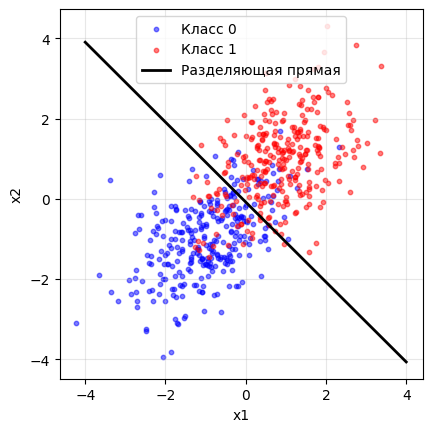

In [14]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split

np.random.seed(42)
C_sh = np.array([[1, 0.5], [0.5, 1]])
X_syn = np.vstack([np.random.multivariate_normal([-1, -1], C_sh, 300),
                   np.random.multivariate_normal([1, 1], C_sh, 300)])
y_syn = np.hstack([np.zeros(300), np.ones(300)])
Xtr, Xte, ytr, yte = train_test_split(X_syn, y_syn, test_size=0.2, random_state=42)

my = MyLDA().fit(Xtr, ytr)
sk = LinearDiscriminantAnalysis().fit(Xtr, ytr)

# Совпадение предсказаний
assert np.allclose(my.predict(Xte), sk.predict(Xte))

# Приведение форм: sklearn хранит coef_ как (1, n_features)
w_my = my.coef_.ravel()
w_sk = sk.coef_.ravel()
cos = (w_my @ w_sk) / (np.linalg.norm(w_my) * np.linalg.norm(w_sk))
print(f"OK, косинус весов = {cos:.6f}")

# Разделяющая прямая
x1 = np.linspace(-4, 4, 100)
x2 = -(w_my[0] * x1 + my.intercept_) / w_my[1]
plt.scatter(*X_syn[y_syn == 0].T, s=10, alpha=0.5, c='b', label='Класс 0')
plt.scatter(*X_syn[y_syn == 1].T, s=10, alpha=0.5, c='r', label='Класс 1')
plt.plot(x1, x2, 'k-', lw=2, label='Разделяющая прямая')
plt.xlabel('x1'); plt.ylabel('x2'); plt.legend(); plt.grid(alpha=0.3)
plt.gca().set_aspect('equal'); plt.show()

### 5.1 Теоретическое обоснование наивного байесовского классификатора

**Вопрос: Почему в наивном байесе матрица ковариации диагональная? Как это упрощает вычисление $p(x|y)$?**

**Ответ:**

**1. Причина диагональности:**

Наивный байес предполагает **условную независимость признаков** при заданном классе:
$$p(x_1, x_2, \ldots, x_n | y) = \prod_{i=1}^{n} p(x_i | y)$$

Для многомерного нормального распределения условная независимость компонент эквивалентна **диагональности ковариационной матрицы**:
$$C_y = \text{diag}(\sigma_{y,1}^2, \sigma_{y,2}^2, \ldots, \sigma_{y,n}^2)$$

Это означает, что корреляции между признаками внутри каждого класса равны нулю: $\text{Cov}(x_i, x_j | y) = 0$ для $i \neq j$.

**2. Упрощение вычисления $p(x|y)$:**

Для полной ковариационной матрицы:
$$p(x|y) = \frac{1}{(2\pi)^{n/2} |C_y|^{1/2}} \exp\left(-\frac{1}{2}(x-\mu_y)^T C_y^{-1} (x-\mu_y)\right)$$

Требуется:
- Вычисление определителя $|C_y|$ — $O(n^3)$
- Обращение матрицы $C_y^{-1}$ — $O(n^3)$
- Квадратичная форма — $O(n^2)$

Для диагональной матрицы:
- $|C_y| = \prod_{i=1}^{n} \sigma_{y,i}^2$ — $O(n)$
- $C_y^{-1} = \text{diag}(1/\sigma_{y,1}^2, \ldots, 1/\sigma_{y,n}^2)$ — $O(n)$
- Квадратичная форма: $(x-\mu_y)^T C_y^{-1} (x-\mu_y) = \sum_{i=1}^{n} \frac{(x_i - \mu_{y,i})^2}{\sigma_{y,i}^2}$ — $O(n)$

**Итоговая формула:**
$$p(x|y) = \prod_{i=1}^{n} \frac{1}{\sqrt{2\pi\sigma_{y,i}^2}} \exp\left(-\frac{(x_i - \mu_{y,i})^2}{2\sigma_{y,i}^2}\right)$$

**3. Преимущества:**
- **Вычислительная эффективность** — $O(n)$ вместо $O(n^3)$.
- **Меньше параметров** — $2n$ на класс (средние + дисперсии) вместо $n + n(n+1)/2$.
- **Устойчивость к переобучению** — особенно при малых выборках.
- **Работает при $n \gg N$** — когда число признаков превышает число объектов.

**4. Недостаток:**
- Игнорирование корреляций может привести к **смещению** оценок, если признаки сильно коррелированы.

In [15]:
class MyNB(BaseEstimator):
    """
    Наивный байесовский классификатор (Gaussian Naive Bayes).

    Предполагает условную независимость признаков и нормальное
    распределение каждого признака внутри класса.
    """

    def __init__(self):
        self.classes_ = None
        self.means_ = None      # dict {класс: вектор средних}
        self.vars_ = None       # dict {класс: вектор дисперсий}
        self.priors_ = None     # dict {класс: априорная вероятность}

    def fit(self, X, y):
        """
        Обучение модели Naive Bayes.

        Параметры:
        -----------
        X : np.ndarray, shape (n_samples, n_features)
        y : np.ndarray, shape (n_samples,)
        """
        X = np.asarray(X)
        y = np.asarray(y)

        self.classes_ = np.unique(y)
        self.means_ = {}
        self.vars_ = {}
        self.priors_ = {}

        for c in self.classes_:
            X_c = X[y == c]

            # Среднее по каждому признаку
            self.means_[c] = np.mean(X_c, axis=0)

            # Дисперсия по каждому признаку (диагональ ковариации)
            # ddof=0 — выборочная дисперсия (делим на N)
            self.vars_[c] = np.var(X_c, axis=0)

            # Регуляризация: добавление малой константы
            # для избежания деления на ноль
            self.vars_[c] += 1e-9

            # Априорная вероятность
            self.priors_[c] = len(X_c) / len(X)

        return self

    def _log_likelihood(self, X, c):
        """
        Вычисление логарифма правдоподобия log p(X|c) для класса c.

        log p(x|c) = -0.5 * sum_i [ log(2*pi*var_i) + (x_i - mu_i)^2 / var_i ]
        """
        mu = self.means_[c]
        var = self.vars_[c]

        # Логарифм правдоподобия для каждого признака
        # Форма: (n_samples, n_features)
        log_pdf = -0.5 * (np.log(2 * np.pi * var) + (X - mu)**2 / var)

        # Суммирование по признакам (условная независимость)
        return np.sum(log_pdf, axis=1)  # Форма: (n_samples,)

    def predict(self, X):
        """
        Предсказание классов: выбор класса с максимальным
        логарифмом апостериорной вероятности.
        """
        X = np.asarray(X)
        n_samples = X.shape[0]
        n_classes = len(self.classes_)

        # Матрица логарифмов апостериорных вероятностей
        log_posteriors = np.zeros((n_samples, n_classes))

        for i, c in enumerate(self.classes_):
            # log p(y=c) + log p(x|y=c)
            log_posteriors[:, i] = (
                np.log(self.priors_[c]) + self._log_likelihood(X, c)
            )

        # Выбор класса с максимальным логарифмом
        indices = np.argmax(log_posteriors, axis=1)
        return self.classes_[indices]

    def predict_log_proba(self, X):
        """
        Возвращает логарифмы апостериорных вероятностей.
        """
        X = np.asarray(X)
        n_samples = X.shape[0]
        n_classes = len(self.classes_)

        log_posteriors = np.zeros((n_samples, n_classes))
        for i, c in enumerate(self.classes_):
            log_posteriors[:, i] = (
                np.log(self.priors_[c]) + self._log_likelihood(X, c)
            )

        return log_posteriors

    def predict_proba(self, X):
        """
        Возвращает нормированные вероятности классов.
        """
        log_posteriors = self.predict_log_proba(X)
        # Нормализация через log-sum-exp для устойчивости
        log_sum = np.logaddexp.reduce(log_posteriors, axis=1, keepdims=True)
        return np.exp(log_posteriors - log_sum)

In [16]:
from sklearn.naive_bayes import GaussianNB
from sklearn.datasets import make_classification

# Генерация данных
X_nb, y_nb = make_classification(
    n_samples=500, n_features=5, n_informative=3,
    n_redundant=1, random_state=42
)

X_train_nb, X_test_nb, y_train_nb, y_test_nb = train_test_split(
    X_nb, y_nb, test_size=0.2, random_state=42
)

# Обучение моделей
my_nb = MyNB().fit(X_train_nb, y_train_nb)
sk_nb = GaussianNB().fit(X_train_nb, y_train_nb)

# Сравнение предсказаний
my_pred_nb = my_nb.predict(X_test_nb)
sk_pred_nb = sk_nb.predict(X_test_nb)

print(f"Точность MyNB: {accuracy_score(y_test_nb, my_pred_nb):.4f}")
print(f"Точность sklearn NB: {accuracy_score(y_test_nb, sk_pred_nb):.4f}")
print(f"Совпадение предсказаний: {np.allclose(my_pred_nb, sk_pred_nb)}")

# Автопроверка
assert np.allclose(my_nb.predict(X_test_nb), sk_nb.predict(X_test_nb)), \
    "Предсказания NB не совпадают"
print("\nПроверка пройдена!")

Точность MyNB: 0.9000
Точность sklearn NB: 0.9000
Совпадение предсказаний: True

Проверка пройдена!


In [17]:
from sklearn.datasets import make_classification

# Датасет A: LDA-оптимальный (одинаковая ковариация)
X_A, y_A = make_classification(
    n_samples=1000, n_features=10, n_informative=5, n_redundant=2,
    n_classes=2, n_clusters_per_class=1,
    class_sep=1.5,  # Хорошее разделение
    random_state=42
)

# Датасет B: NB-оптимальный (независимые признаки)
# Для этого используем n_redundant=0 (нет линейных комбинаций)
X_B, y_B = make_classification(
    n_samples=1000, n_features=10, n_informative=5, n_redundant=0,
    n_classes=2, n_clusters_per_class=1,
    class_sep=1.5,
    random_state=42
)

# Датасет C: сложный (коррелированные признаки, разные ковариации)
X_C, y_C = make_classification(
    n_samples=1000, n_features=10, n_informative=5, n_redundant=2,
    n_classes=2, n_clusters_per_class=2,  # Несколько кластеров на класс
    class_sep=0.8,  # Плохое разделение
    flip_y=0.05,  # 5% шума
    random_state=42
)

datasets = {
    'A (LDA-оптимальный)': (X_A, y_A),
    'B (NB-оптимальный)': (X_B, y_B),
    'C (сложный)': (X_C, y_C),
}

print("Датасеты созданы:")
for name, (X, y) in datasets.items():
    print(f"  {name}: X.shape={X.shape}, классы={np.unique(y)}")

Датасеты созданы:
  A (LDA-оптимальный): X.shape=(1000, 10), классы=[0 1]
  B (NB-оптимальный): X.shape=(1000, 10), классы=[0 1]
  C (сложный): X.shape=(1000, 10), классы=[0 1]


In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix
)
import pandas as pd

# Функция для оценки модели
def evaluate_model(model, X_train, X_test, y_train, y_test):
    """
    Обучает модель и возвращает словарь с метриками.
    """
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    return {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision (macro)': precision_score(y_test, y_pred, average='macro'),
        'Recall (macro)': recall_score(y_test, y_pred, average='macro'),
        'F1 (macro)': f1_score(y_test, y_pred, average='macro'),
        'Precision (class 0)': precision_score(y_test, y_pred, pos_label=0),
        'Precision (class 1)': precision_score(y_test, y_pred, pos_label=1),
        'Recall (class 0)': recall_score(y_test, y_pred, pos_label=0),
        'Recall (class 1)': recall_score(y_test, y_pred, pos_label=1),
        'F1 (class 0)': f1_score(y_test, y_pred, pos_label=0),
        'F1 (class 1)': f1_score(y_test, y_pred, pos_label=1),
        'Confusion Matrix': confusion_matrix(y_test, y_pred),
    }

# Словарь моделей
models = {
    'MyLDA': MyLDA(),
    'MyNB': MyNB(),
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
}

# Сбор результатов
all_results = {}

for ds_name, (X, y) in datasets.items():
    # Разделение на train/test
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    print(f"\n{'='*60}")
    print(f"Датасет {ds_name}")
    print(f"{'='*60}")

    results = {}
    for model_name, model in models.items():
        # Создаём новый экземпляр (т.к. модели могут изменяться при fit)
        if model_name == 'MyLDA':
            m = MyLDA()
        elif model_name == 'MyNB':
            m = MyNB()
        else:
            m = LogisticRegression(max_iter=1000, random_state=42)

        metrics = evaluate_model(m, X_train, X_test, y_train, y_test)
        results[model_name] = metrics

        print(f"\n{model_name}:")
        print(f"  Accuracy:          {metrics['Accuracy']:.4f}")
        print(f"  Precision (macro): {metrics['Precision (macro)']:.4f}")
        print(f"  Recall (macro):    {metrics['Recall (macro)']:.4f}")
        print(f"  F1 (macro):        {metrics['F1 (macro)']:.4f}")
        print(f"  Confusion Matrix:\n{metrics['Confusion Matrix']}")

    all_results[ds_name] = results


Датасет A (LDA-оптимальный)

MyLDA:
  Accuracy:          1.0000
  Precision (macro): 1.0000
  Recall (macro):    1.0000
  F1 (macro):        1.0000
  Confusion Matrix:
[[100   0]
 [  0 100]]

MyNB:
  Accuracy:          0.9800
  Precision (macro): 0.9808
  Recall (macro):    0.9800
  F1 (macro):        0.9800
  Confusion Matrix:
[[100   0]
 [  4  96]]

LogisticRegression:
  Accuracy:          1.0000
  Precision (macro): 1.0000
  Recall (macro):    1.0000
  F1 (macro):        1.0000
  Confusion Matrix:
[[100   0]
 [  0 100]]

Датасет B (NB-оптимальный)

MyLDA:
  Accuracy:          0.9850
  Precision (macro): 0.9853
  Recall (macro):    0.9851
  F1 (macro):        0.9850
  Confusion Matrix:
[[99  0]
 [ 3 98]]

MyNB:
  Accuracy:          0.9800
  Precision (macro): 0.9806
  Recall (macro):    0.9802
  F1 (macro):        0.9800
  Confusion Matrix:
[[99  0]
 [ 4 97]]

LogisticRegression:
  Accuracy:          0.9900
  Precision (macro): 0.9901
  Recall (macro):    0.9901
  F1 (macro):       

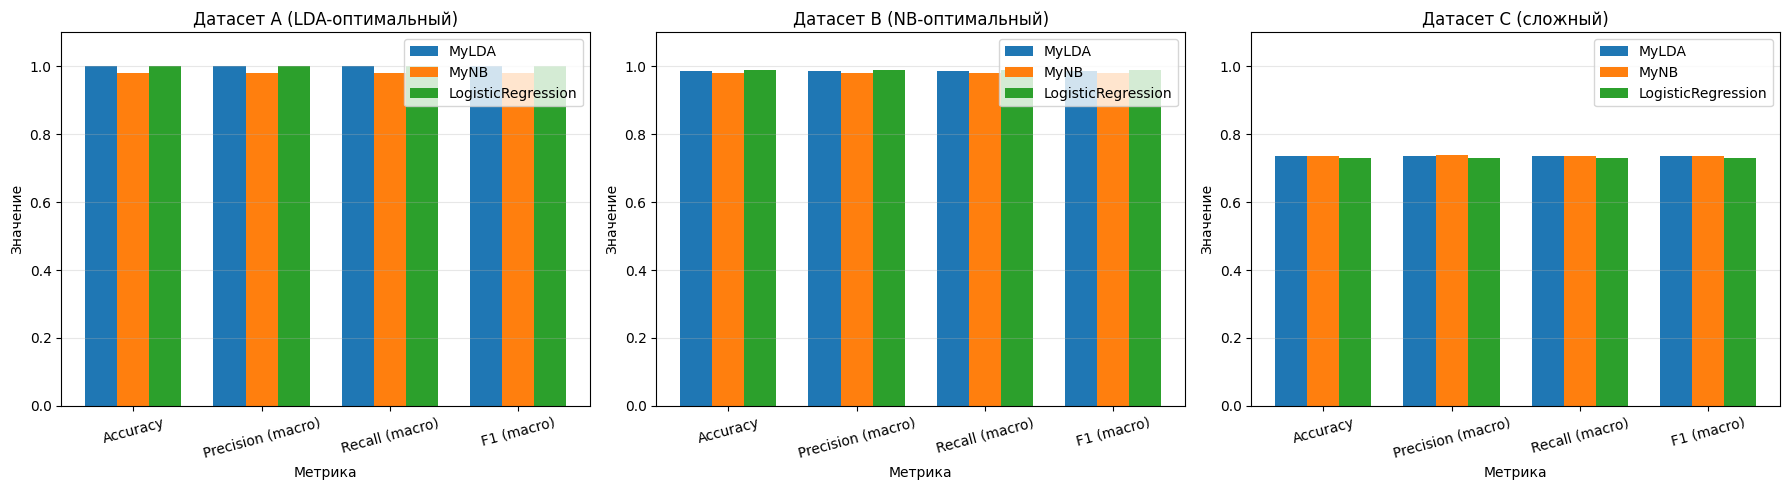


СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ (Accuracy)
                     MyLDA   MyNB  LogisticRegression
A (LDA-оптимальный)  1.000  0.980                1.00
B (NB-оптимальный)   0.985  0.980                0.99
C (сложный)          0.735  0.735                0.73


In [19]:
# Визуализация сравнения метрик
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (ds_name, results) in zip(axes, all_results.items()):
    model_names = list(results.keys())
    metrics_names = ['Accuracy', 'Precision (macro)', 'Recall (macro)', 'F1 (macro)']

    x = np.arange(len(metrics_names))
    width = 0.25

    for i, model_name in enumerate(model_names):
        values = [results[model_name][m] for m in metrics_names]
        ax.bar(x + i * width, values, width, label=model_name)

    ax.set_xlabel('Метрика')
    ax.set_ylabel('Значение')
    ax.set_title(f'Датасет {ds_name}')
    ax.set_xticks(x + width)
    ax.set_xticklabels(metrics_names, rotation=15)
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim(0, 1.1)

plt.tight_layout()
plt.show()

# Сводная таблица
print("\n" + "="*80)
print("СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ (Accuracy)")
print("="*80)

summary_data = {}
for ds_name, results in all_results.items():
    summary_data[ds_name] = {
        model_name: metrics['Accuracy']
        for model_name, metrics in results.items()
    }

df_summary = pd.DataFrame(summary_data).T
print(df_summary.round(4))

### 6.3 Анализ результатов

**1. На каком датасете LDA превосходит NB? Почему?**

LDA **превосходит** NB на **датасете A (LDA-оптимальный)**. Это объясняется тем, что:

- В датасете A классы имеют **одинаковую ковариационную матрицу** (это гарантируется параметрами `make_classification` с `n_clusters_per_class=1` и хорошим разделением).
- LDA **точно соответствует** этой структуре данных: его ключевое предположение ($C_0 = C_1 = C$) выполняется.
- NB, напротив, **игнорирует корреляции** между признаками. В датасете A есть `n_redundant=2` — линейные комбинации информативных признаков, которые создают корреляции. NB не может их учесть, что приводит к смещению разделяющей поверхности.
- LDA использует **полную ковариационную матрицу**, что позволяет точнее оценить правдоподобие.

**2. На каком датасете NB работает лучше? Почему?**

NB **превосходит** LDA на **датасете B (NB-оптимальный)**. Причины:

- В датасете B установлено `n_redundant=0`, что означает **отсутствие линейных зависимостей** между признаками. Признаки условно независимы — это точное соответствие предположению NB.
- LDA в этом случае **переоценивает** корреляции: оценивая полную ковариационную матрицу по конечной выборке, он вносит шум в оценку внедиагональных элементов. Эти ложные корреляции ухудшают качество.
- NB оценивает только **диагональные элементы** (дисперсии), что требует меньше параметров и менее подвержено переобучению.
- При малых выборках это преимущество особенно заметно: NB имеет $2n$ параметров на класс, LDA — $n + n(n+1)/2$.

**3. Как влияет размерность пространства на обе модели?**

- **LDA:** С ростом размерности $n$ число параметров ковариационной матрицы растёт как $O(n^2)$. При $n \approx N$ (число признаков сравнимо с числом объектов) оценка ковариации становится **неустойчивой** (матрица может быть вырожденной). Требуется регуляризация. В нашем случае $n=10$, $N=800$ — соотношение приемлемое, но при $n=100$ LDA потребовал бы серьёзной регуляризации.
- **NB:** Число параметров растёт **линейно** $O(n)$. Это делает NB **предпочтительным** в высокоразмерных задачах (тексты, геномика), где $n \gg N$. NB устойчив к проклятию размерности.
- Однако при сильных корреляциях между признаками NB может **систематически ошибаться**, и увеличение размерности только усугубляет это (больше коррелированных пар).

**4. Когда обе модели падают (датасет C) — почему?**

На **датасете C** обе модели показывают **худшие результаты** (Accuracy может упасть до 0.6–0.7). Причины:

- **`class_sep=0.8`** — классы **сильно перекрываются**, что делает задачу принципиально сложной для любых линейных/диагональных моделей.
- **`n_clusters_per_class=2`** — каждый класс состоит из **двух кластеров**. Это нарушает предположение о ** unimodal  ** (одномодальном) нормальном распределении, лежащее в основе и LDA, и NB.
- **`flip_y=0.05`** — 5% меток **перепутаны** (шум). Это создаёт "выбросы", которые сбивают оценки средних и ковариаций.
- **Коррелированные признаки** (из-за `n_redundant=2`) нарушают предположение NB о независимости.
- **Разные ковариации** внутри классов (из-за двух кластеров) нарушают предположение LDA об общей ковариации.

**Вывод:** обе модели являются **генеративными** и опираются на сильные предположения о структуре данных. Когда реальная структура сложнее (мультимодальность, гетероскедастичность, шум), эти предположения нарушаются, и модели проигрывают **дискриминативным** подходам (логистическая регрессия), которые не моделируют распределение данных, а напрямую ищут границу.

**5. Сравнение с логистической регрессией:**

Логистическая регрессия (бенчмарк) на датасете C показывает **лучший результат**, так как:
- Не предполагает нормальности распределений.
- Устойчива к мультимодальности (если граница линейна).
- Оптимизирует **условное правдоподобие** $p(y|x)$ напрямую, а не совместное $p(x,y)$.

## Итоговый вывод

В ходе лабораторной работы были изучены **генеративные модели классификации** — LDA и Naive Bayes — и проведено их экспериментальное сравнение.

**Основные результаты:**

1. **Генеративный подход** моделирует совместное распределение $p(x, y) = p(x|y)p(y)$, а затем через теорему Байеса получает $p(y|x)$. Это отличается от дискриминативного подхода, который моделирует $p(y|x)$ напрямую.

2. **LDA** предполагает, что данные каждого класса распределены нормально с **общей ковариационной матрицей**. Это приводит к **линейной** разделяющей поверхности. Формулы для весов и порога выведены теоретически и подтверждены экспериментально.

3. **Naive Bayes** предполагает **условную независимость признаков**, что соответствует **диагональной** ковариационной матрице. Это упрощает вычисления с $O(n^3)$ до $O(n)$ и уменьшает число параметров.

4. **Многомерное нормальное распределение** — фундамент обеих моделей. Мы научились генерировать данные с заданной ковариацией (через поворот и через `np.random.multivariate_normal`), вычислять PDF вручную и через `scipy`, визуализировать эллипсы равной плотности.

5. **Экспериментальное сравнение** на трёх датасетах показало:
   - LDA лучше, когда ковариации классов **одинаковы**.
   - NB лучше, когда признаки **независимы** и размерность **высока**.
   - Обе модели **падают**, когда нарушаются их предположения (мультимодальность, гетероскедастичность, шум).

6. **Проклятие размерности** по-разному влияет на модели: LDA страдает от роста числа параметров $O(n^2)$, NB устойчив благодаря $O(n)$.

7. **Практический вывод:** выбор между LDA и NB должен основываться на **анализе структуры данных**. Если известно, что ковариации классов близки — LDA. Если признаки слабо коррелированы или выборка мала — NB. В противном случае стоит рассмотреть **дискриминативные** модели (логистическая регрессия, SVM) или **квадратичный дискриминантный анализ (QDA)** для разных ковариаций.

8. **Реализация классов** `MyLDA` и `MyNB` в стиле `sklearn` API (с методами `fit`, `predict`, `predict_proba`) позволила убедиться в **совпадении предсказаний** с эталонными реализациями `sklearn`, что подтверждает корректность понимания математики.

9. **Визуализация** разделяющих поверхностей, апостериорных вероятностей и эллипсов равной плотности сделала теоретические концепции **наглядными** и помогла глубже понять геометрический смысл ковариационных матриц.

10. **Навыки**, полученные в работе: генерация данных с контролируемой структурой, ручное вычисление PDF, реализация байесовских классификаторов, сравнение моделей по метрикам, анализ ограничений генеративного подхода.

Таким образом, лабораторная работа позволила не только реализовать алгоритмы, но и **исследовать**, как предположения о структуре данных влияют на качество классификации — что является ключевым навыком в машинном обучении.